# Convolutional network for image classification

The goal of this exercise is to build a simple convolutional network for classifying images into 10 classes.

## Dataset

Cifar10 is a dataset of 50,000 color training images 32x32 in size and 10,000 test images, labeled into 10 categories.

More information can be found at https://www.cs.toronto.edu/~kriz/cifar.html

## Classes
- 0 	airplane
- 1 	automobile
- 2 	bird
- 3 	cat
- 4 	deer
- 5 	dog
- 6 	frog
- 7 	horse
- 8 	ship
- 9 	truck

# Loading the dataset
Again, this is a well-known dataset, so keras has the cifar10 function ready for it.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

We will name the loaded classes according to the well-known order.

In [ ]:
class_names=["plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
num_classes = len(class_names)

# Data exploration
We don't yet know anything about the data, so let's take a look at it.

The sizes of the numpy arrays show us:
* There are 50000 training data
* There are 10000 test data
* The images are 32x32 in size
* The images are in color, because we have 3 RGB channels

In [ ]:
print('X_train: ' + str(X_train.shape))
print('Y_train: ' + str(y_train.shape))
print('X_test:  '  + str(X_test.shape))
print('Y_test:  '  + str(y_test.shape))

We can print the raw data for the first image. We can see that the values are stored in the uint(8) data type, which has a range of 0..255.

In [ ]:
X_train[0]

There should be 10 classes of images, so we will look at the unique values in the Y_train and Y_test arrays. We want all the classes to be represented in them.

In [ ]:
print(np.unique(y_train))
print(np.unique(y_test))

A good dataset is balanced. Each class should have a similar number of images.

Let's plot the chart of class frequencies.

In [ ]:
sns.displot(y_train)

In [ ]:
sns.displot(y_test)

# Data visualization
These are images. So let's display a preview of them.

We can see that the images are quite small, and for some of them it's hard even for a human to determine what's in them.

In [ ]:
def show_images (images, labels, rows=6, cols=10):
    fig, axes = plt.subplots(rows, cols, figsize=(cols, rows))
    plt.subplots_adjust(bottom=0)
    
    for idx in range (0, rows * cols):
        ridx=idx//cols
        cidx=idx % cols        
        ax= axes[ridx, cidx]
        ax.axis("off")
        ax.imshow(images[idx])
        label = class_names[labels[idx][0]]
        ax.set_title(f"{label}")        

In [ ]:
show_images(X_train, y_train, 3, 10)

# Data preparation
The range of values is 0 to 255. The data type is uint8.

Neural networks work better with standardized values around 0.

So we will change the data type to float32 and standardize the data by dividing by 255. This gives us a range of 0..1

In [ ]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

X_train = X_train / 255
X_test = X_test / 255

Checking the raw data.

In [ ]:
X_train[0]

The output categories in the input data are again stored as a class number.

For the neural network, we will want the output data in the form of a vector.

We perform one-hot encoding.

In [ ]:
from keras.utils import to_categorical
num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

Checking the output data.

In [ ]:
y_train[0]

# Convolutional neural network using Keras

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, Input

A convolutional neural network is feedforward / sequential.

In [ ]:
model = Sequential()

Unlike classical networks, convolutional networks work with the spatial structure of the input data. That's why we won't convert the input data into a one-dimensional vector, but will keep it in the form of a matrix.

In [ ]:
model.add(Input(shape=(32,32,3)))

We add the first convolutional layer.
* filters     - 32 convolutional filters
* kernel_size - the size of the convolutional filters, 3 x 3
* padding     - "same" padding results in even padding left/right or up/down around the input
* activation  - the ReLU activation function

In [ ]:
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'))

We add another convolutional layer.

In [ ]:
model.add(Conv2D(32, (3,3), padding='same', activation='relu'))

A max-pooling layer follows the pair of convolutional layers.

It reduces the size of the matrices using a 2x2 pool.

In [ ]:
model.add(MaxPooling2D(pool_size=(2,2)))

To make our neural network more resistant to overfitting, we add a Dropout layer.

The Dropout layer randomly sets input neurons to 0, which helps prevent the network from overfitting the training data.

The inputs that are not set to 0 are scaled by 1 / (1 - rate) so that the sum of all the inputs does not change.

In [ ]:
model.add(Dropout(0.3))

Then we add a second block of convolutional, max-pooling, and dropout layers.

In [ ]:
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.5))

Third block

In [ ]:
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.5))

After a series of convolutional layers, we need to build the part of the network that will convert the values into categories.

The Flatten layer flattens the multidimensional arrays we have so far into 1 dimension.

In [ ]:
model.add(Flatten())

The classification part with fully connected layers using the ReLU activation function.

In [ ]:
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

The last layer has 10 output neurons, because we have 10 image classes.

The softmax activation function is used, which converts the values into probabilities.

In [ ]:
model.add(Dense(num_classes, activation='softmax')) 

Let's display the model.

In [ ]:
model.summary()

In [ ]:
from keras_visualizer import visualizer 
visualizer(model, file_format='png', view=True)

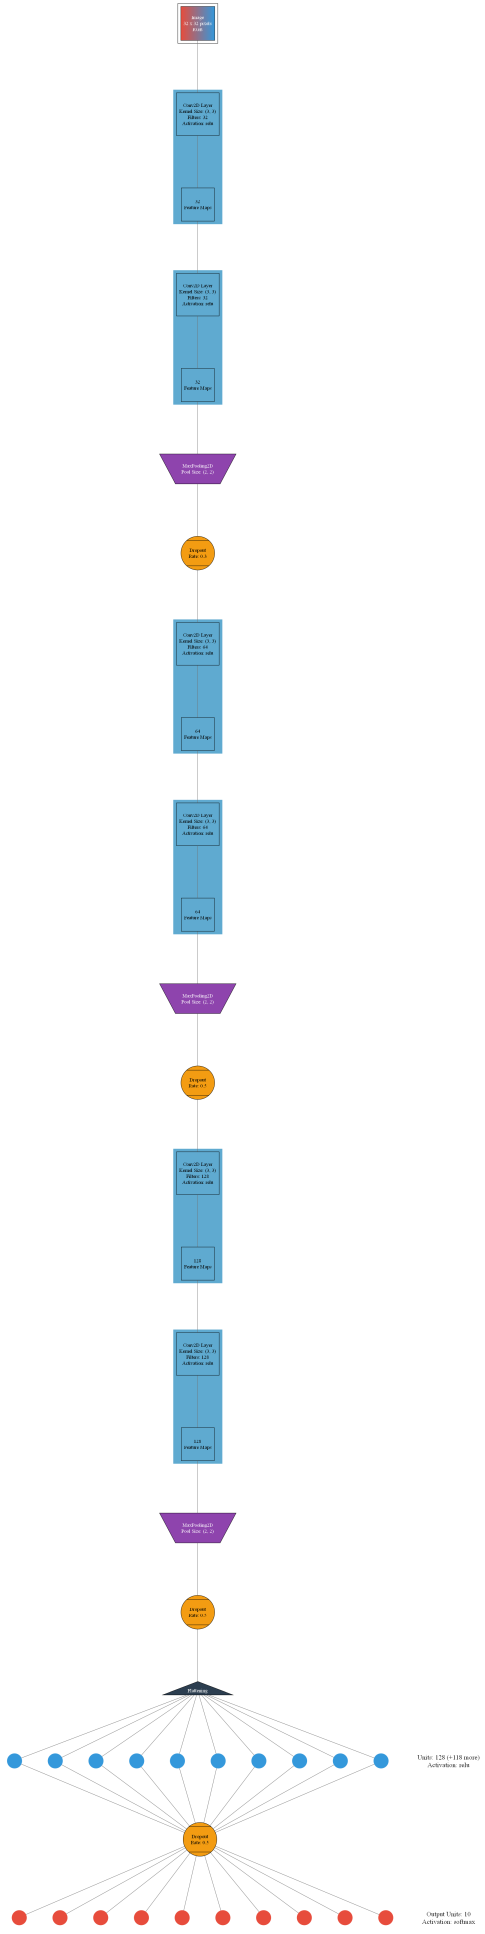

## Training

We set the training parameters.

In [ ]:
model.compile(optimizer='adam', loss="categorical_crossentropy", metrics=['accuracy'])

We create an EarlyStopping callback, so we don't needlessly keep training an already trained network.

In [ ]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=30)

Let's run the network training.

Training a more complex model takes longer, so the number of epochs is set to 15.

To achieve better results, the number of epochs can be increased.

In [ ]:
history = model.fit(X_train, y_train, batch_size=64, epochs=15, validation_split=0.1, callbacks=[early_stop])

We will save the trained network to a file for later use.

In [ ]:
model.save('classification_model_cifar10.keras')

## Training history
Again, it's a good idea to look at the training process, to check whether the cost function value is decreasing.

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend(loc="upper right")
plt.title('Loss, Accuracy')
plt.ylabel('Loss, Accuracy')
plt.xlabel('Number of epochs')
plt.show()

## Model verification
We must verify the trained model on the test data.

In [ ]:
model = keras.models.load_model('classification_model_cifar10.keras')

In [ ]:
y_pred = model.predict(X_test)

Let's compare the prediction to the correct answer for the first image.

In [ ]:
y_pred[0]

With the correct answer.

In [ ]:
y_test[0]

We get the result as a vector of probabilities. So we get a single answer by finding the maximum.

In [ ]:
y_pred_best_answer = np.argmax(y_pred, axis=-1)
y_pred_best_answer

We do the same for the test answers (the ground truth).

Ideally, both arrays should be equal.

In [ ]:
y_test_best_answer=np.argmax(y_test, axis=-1)
y_test_best_answer

Let's plot the confusion matrix.

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
cf_matrix = confusion_matrix(y_test_best_answer, y_pred_best_answer)
sns.heatmap(cf_matrix, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.show()

Let's display the evaluation metrics
* Accuracy

In [ ]:
scores = model.evaluate(X_test, y_test, verbose=0)
print (f"Loss function: {scores[0]}")
print (f"Accuracy: {scores[1]}")

### ROC curves
ROC curves show the trade-off between sensitivity (True Positive Rate) and the false positive rate (False Positive Rate) for various threshold values.

For 10 classes, they are drawn using the **one-vs-rest** method — each class is compared against all the others. An **AUC** close to 1 indicates a good classifier.

In [ ]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(9, 6))
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — one vs rest (Keras)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

We can display the accuracy for each image class.

In [ ]:
class_correct, class_count = [0]*10, [0]*10

for i in range(y_test.shape[0]):    
    if (y_test_best_answer[i] == y_pred_best_answer[i]):
        class_correct[y_test_best_answer[i]] +=1
    class_count[y_test_best_answer[i]] += 1
    
for i in range(10):
    print (f"Accuracy for {class_names[i]}: {class_correct[i]/class_count[i]:.2%}") 

It can be interesting to look at the incorrect answers.

In [ ]:
def show_wrong_predictions(X_test, Y_test, Y_pred, rows=5, cols=5):
    """Show misclassified examples. Title format: true != predicted."""
    idx = 0
    max_examples = rows * cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols, rows), constrained_layout=True)
    for i in range(Y_test.shape[0]):
        if Y_test[i] != Y_pred[i]:
            ridx = idx // cols
            cidx = idx % cols
            ax = axes[ridx, cidx]
            ax.axis("off")
            ax.imshow(X_test[i].reshape(32, 32, 3))
            ax.set_title(f"{class_names[Y_test[i]]} != {class_names[Y_pred[i]]}")
            idx += 1
            if idx == max_examples:
                break

In [ ]:
show_wrong_predictions(X_test, y_test_best_answer, y_pred_best_answer, 2, 10)

# Convolutional network in PyTorch
We will build the same network using the PyTorch framework.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

## Loading and preparing the data

Preparing the transform function (normalization + conversion to tensor)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

Since cifar10 is well known again, downloading it is built into pytorch.

In [ ]:
train_dataset = datasets.CIFAR10(root='.', train=True, download=True, transform=transform)
test_dataset  = datasets.CIFAR10(root='.', train=False, download=True, transform=transform)

When training on the GPU, data needs to be transferred from CPU memory to GPU memory. This overhead slows down training. It's a good idea to increase the amount transferred per cycle.

That's why the batch size was increased to 1024.

If you monitor GPU memory usage, this value could be increased even further.

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1024)

## GPU
Checking whether a GPU is available.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

## Network model

In the model, we can already see that the network consists of two parts:
* the convolutional network, which looks for features
* the sequential network, which performs classification based on the features found

The forward method calls these two sub-networks in turn

In [ ]:
class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Creating the network and loading it onto the GPU

In [ ]:
model = CIFAR10_CNN()
model.to(device)

## Training parameters

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_acc = 0
patience = 5
epochs_no_improve = 0
epochs = 50

history_loss = []
history_acc = []

## Training

In [ ]:
for epoch in range(epochs):
    
    model.train()
    train_losses = []
    train_accs = []

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        preds = outputs.argmax(dim=1)
        acc = (preds == y_batch).float().mean().item()
        train_accs.append(acc)

    epoch_loss = np.mean(train_losses)
    epoch_acc = np.mean(train_accs)
    history_loss.append(epoch_loss)
    history_acc.append(epoch_acc)

    print(f"Epoch {epoch+1}: loss={epoch_loss:.4f}, acc={epoch_acc:.4f}")

    if epoch_acc > best_acc:
        best_acc = epoch_acc
        best_state = model.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping!")
            break

model.load_state_dict(best_state)

## Training history

In [ ]:
plt.plot(history_loss, label="Train Loss")
plt.plot(history_acc, label="Train Accuracy")
plt.legend()
plt.title("Loss, Accuracy")
plt.show()

## Model verification

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1)
        all_preds.append(preds)
        all_labels.append(y_batch)

y_pred_best_answer = torch.cat(all_preds).cpu().numpy()
y_test_best_answer = torch.cat(all_labels).cpu().numpy()

In [ ]:
acc = accuracy_score(y_test_best_answer, y_pred_best_answer)
print("Accuracy:", acc)

## Confusion matrix

In [ ]:
cf = confusion_matrix(y_test_best_answer, y_pred_best_answer)
sns.heatmap(cf, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.show()

## ROC curves
The PyTorch model returns logits — for ROC curves we need softmax, to get probabilities for each class.

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# collect softmax probabilities from all test batches
model.eval()
all_probs  = []
all_labels = []
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        logits = model(x_batch)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y_batch.numpy())

y_prob = np.concatenate(all_probs)
y_true = np.concatenate(all_labels)
y_true_bin = label_binarize(y_true, classes=list(range(10)))

fig, ax = plt.subplots(figsize=(9, 6))
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — one vs rest (PyTorch)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Saving the model

In [ ]:
torch.save(model.state_dict(), "classification_cifar10_model.pt")

## Model inference

In [ ]:
model = CIFAR10_CNN()
model.load_state_dict(torch.load("classification_cifar10_model.pt", weights_only=True))
model.to(device)
model.eval()

Classifying a single image

In [ ]:
sample = test_dataset[0][0].unsqueeze(0)

with torch.no_grad():
    sample = sample.to(device)
    logits = model(sample)
    probs = torch.softmax(logits, dim=1).cpu().numpy()

print("Probabilities:", probs)
print("Predicted class:", np.argmax(probs))

Accuracy of determining the individual classes

In [ ]:
class_correct, class_count = [0]*10, [0]*10

for i in range(len(y_test_best_answer)):
    if y_test_best_answer[i] == y_pred_best_answer[i]:
        class_correct[y_test_best_answer[i]] += 1
    class_count[y_test_best_answer[i]] += 1

for i in range(10):
    print(f"Accuracy for {class_names[i]}: {class_correct[i]/class_count[i]:.2%}")

Incorrectly determined images

In [ ]:
show_wrong_predictions(X_test, y_test_best_answer, y_pred_best_answer, 2, 10)